In [37]:
# !pip install ucimlrepo

In [38]:
import numpy as np
import pandas as pd
import seaborn as sns


from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.mixture import GaussianMixture
from sklearn.metrics import mean_absolute_error
from nltk.cluster.kmeans import KMeansClusterer
from nltk.cluster.util import euclidean_distance
from sklearn.impute import KNNImputer
from sklearn.decomposition import PCA

import umap.umap_ as umap
import matplotlib.pyplot as plt

# Exploring the SUPPORT2 Dataset

In [39]:
# --------------------------- Explore dataset ------------------------------
# copied from ucimlrepo web
from ucimlrepo import fetch_ucirepo

# fetch dataset
support2 = fetch_ucirepo(id=880)

# data (as pandas dataframes)
features = support2.data.features
targets = support2.data.targets

In [40]:
# join together as 1 df for EDA 
df = features.join(targets)
df = df.drop(columns=['death', 'hospdead']) # drop other target features

**Observations:** Some categories/features have lots of missing values (i.e., 'bun', 'urine', 'adlp'). More than half of the values are missing for these features. See "Dealing with Missing Values" section later...

# Feature Encoding

There are a lot of non-numerics. 

Some helper functions for encoding below: 

In [41]:
def dummy_encode(data, categories):    

    encoder = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False) # initialize encoder
    encoded_data = encoder.fit_transform(data[categories]) # fit and transform data via encoder 

    new_cols = encoder.get_feature_names_out()
    data[new_cols] = encoded_data 

    return data.drop(columns=categories) # drop from df after encoding 

In [42]:
def ordinal_encode(data, column, category_order):  

    encoder = OrdinalEncoder(categories=[category_order], handle_unknown="use_encoded_value", unknown_value=np.nan) # initialize encoder with category order; handle unknowns
    encoded_data = encoder.fit_transform(data[[column]])

    new_col = encoder.get_feature_names_out() 
    data[new_col] = encoded_data # update df with encoded values 

    return data 

In [43]:
# columns that contain non-numerical values -> these have to be encoded 
non_numerics = df.select_dtypes(exclude=['number'])
non_numerics_cols = non_numerics.columns

print(f"Columns with on-numerical values: {', '.join(non_numerics_cols)}")

Columns with on-numerical values: sex, dzgroup, dzclass, income, race, ca, dnr, sfdm2


In [50]:
# make copy of original df to prevent modifying original (df's are mutable)

df_encoded = df.copy()

# -------------- nominal data --------------
# one-hot-encoding (order does not matter)
df_encoded = dummy_encode(df_encoded, ['sex','dzgroup', 'dzclass', 'race', 'ca', 'dnr'])

# -------------- ordinal data --------------
# ordinal data -> ordinal encoding 

# income: lower income = 0, higher income = 3
# note: order matters, but actual selected numbers are arbitrary 
income_order = ['nan', 'under $11k', '$11-$25k', '$25-$50k', '>$50k']
df_encoded = ordinal_encode(df_encoded, 'income', category_order=income_order)

# sfdm2 (target): 0 = better outcome; 5 = dead 
sfdm2_order = ['nan', 'no(M2 and SIP pres)', 'adl>=4 (>=5 if sur)', 'SIP>=30', 'Coma or Intub',  '<2 mo. follow-up']
df_encoded = ordinal_encode(df_encoded, 'sfdm2', category_order=sfdm2_order)

# Dealing with Missing Data

Previously, revealed that some features have a lot of missing data. Deal with missing values before scaling.

In [51]:
# determine the number of NaN's per column 
nan_counts = df_encoded.isna().sum()

## Target

In [52]:
# 1400 entries have missing target (sfdm2) -> drop these rows 
# effective dataset size will decrease 

df_encoded = df_encoded.dropna(subset=['sfdm2'])

## Features

In [53]:
# drop all columns where there is A LOT (>50%) missing data 
# results from 277A_db_explore.ipynb: [('urine', 53), ('adlp', 61)]

df_encoded = df_encoded.drop(columns=['urine', 'adlp'])

In [54]:
# use imputation for other features -> first split into targets vs features to prevent data leakage 
X = df_encoded.drop(columns=['sfdm2'])
y = df_encoded['sfdm2']

# split into training vs test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(6164, 55) (6164,)
(1541, 55) (1541,)


In [55]:
# also scale data before KNN imputation 
scalar = StandardScaler()
# scalar = MinMaxScaler()

X_train_S = scalar.fit_transform(X_train) # fit and transform to training data 
X_test_S = scalar.transform(X_test) # only transform test data 

# convert back into pandas df 
X_train_S = pd.DataFrame(X_train_S, columns=X_train.columns)
X_test_S = pd.DataFrame(X_test_S, columns=X_test.columns)

In [56]:
# to verify n_neighbors of KNN, withhold some data for validation 

print(f"Number of missing vals in X_train: {X_train_S.isna().any(axis=1).sum()}") 

# get only rows that do not have nan
X_train_copy = X_train_S.dropna()
y_train_copy = y_train.iloc[X_train_copy.index] # already dropped all nan from target, get rows with matching index 

# confirm shape (num rows) match 
print(X_train_copy.shape, y_train_copy.shape) 

# problem: which is the best n_neighbors for this dataset? 
# randomly introduce missing data to the complete copy dataset 
missing_pct = 0.2 # change this value to change amount of random 
rand_idx = np.random.randint(0, len(X_train_copy), int(len(X_train_copy) * missing_pct)) # select random indices -> will replace with nan  

X_missing = X_train_copy.copy() # create new df with missing vals 
X_missing.iloc[rand_idx] = np.nan
# X_missing.sample(15) # verify

Number of missing vals in X_train: 5563
(601, 55) (601,)


In [57]:
range_k = np.arange(1, 6, 1)

error = [None] * len(range_k)

for idx, k in enumerate(range_k): 
    imputer = KNNImputer(n_neighbors=k) # initialize imputer 
    X_train_I = imputer.fit_transform(X_missing) # fit and transform training set 
    X_train_I = pd.DataFrame(X_train_I, columns=X_missing.columns, index=X_missing.index)

    replaced_rows = X_train_I.iloc[rand_idx] # imputed 
    true_vals = X_train_copy.iloc[rand_idx] # true values 

    # mean absolute error 
    error[idx] = np.nanmean(np.abs(replaced_rows - true_vals).mean(axis=1))

print(error)

[np.float64(0.679956515962337), np.float64(0.679956515962337), np.float64(0.679956515962337), np.float64(0.679956515962337), np.float64(0.679956515962337)]


In [58]:
# now, fill in for actual dataset 
knn_imputer = KNNImputer(n_neighbors=1) # use k from best fit above 
X_train_I = knn_imputer.fit_transform(X_train)
X_test_I = knn_imputer.transform(X_test)

In [59]:
# final dataset
X_train = pd.DataFrame(X_train_I, columns=X_train.columns)
X_test = pd.DataFrame(X_test_I, columns=X_test.columns)

# confirm all values are now non-null 
print(f"Contains missing values: {X_train.isna().any().any()}")
print(f"Contains missing values: {X_test.isna().any().any()}")

Contains missing values: False
Contains missing values: False


In [60]:
# cast targets to type int -> classification 
y_train = y_train.astype(int)
y_test = y_test.astype(int)

## PCA to reduce dimensionality 

In [61]:
# refit with n_components = 3 
# pca = PCA(n_components=3)
# pca = PCA(n_components=3)
# X_train_pca = pca.fit_transform(X_train, y_train)
# X_test_pca = pca.transform(X_test)
X_train_pca = X_train
X_test_pca = X_test

## Testing models on preprocessed data

In [62]:
from models import *

#### testing multinomial log regression

In [63]:
# testing multinomial log regression
MN_LogReg = MN_Logistic_Regression_model(num_classes=5,
                                         x_train=X_train_pca,
                                         y_train=y_train,
                                         x_test=X_test_pca,
                                         y_test=y_test)

/Users/anika/miniconda3/envs/MSSE_python/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


training accuracy: 49.84%
testing accuracy: 49.90%
None
{'MAX ENTROPY': 2.321928094887362, 0: '1.67', 1: '1.84', 2: '1.70', 3: '1.66', 4: '1.70'}


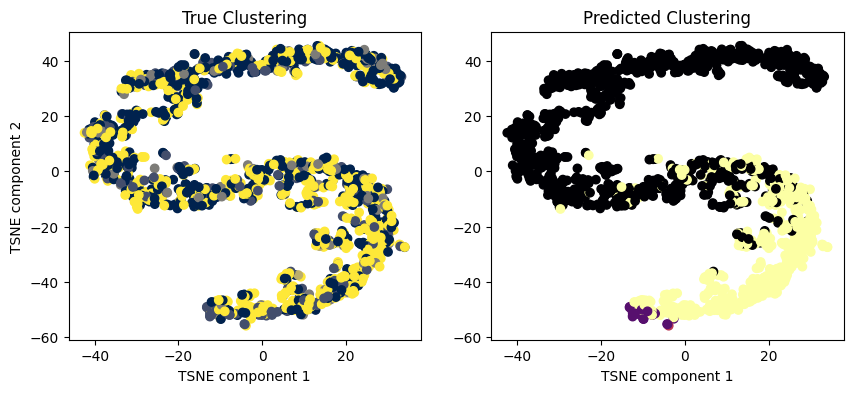

In [64]:
print(MN_LogReg.get_accuracies())
print(MN_LogReg.get_entropy())
MN_LogReg.visualize_clustering()

#### unsupervised method - GMM

In [65]:
# unsupervised method - GMM
y_test_df = pd.DataFrame(y_test, columns=['sfdm2'])
GMM = Gaussian_Mixture_model(num_components=5,
                             rand_state=0,
                             x_data=X_test_pca,
                             y_data=y_test_df,
                             target='sfdm2')

/Users/anika/MSSE Spring 2026/Chem-277A/277A_Final_Project/models.py:43: RuntimeWarning: divide by zero encountered in log2
  cluster_entropy = float(-np.sum(cluster_probabilities * np.log2(cluster_probabilities)))
/Users/anika/MSSE Spring 2026/Chem-277A/277A_Final_Project/models.py:43: RuntimeWarning: invalid value encountered in multiply
  cluster_entropy = float(-np.sum(cluster_probabilities * np.log2(cluster_probabilities)))


{'MAX ENTROPY': 2.321928094887362, 0: '1.66', 1: '1.96', 2: '1.68', 3: '1.45', 4: 'nan'}


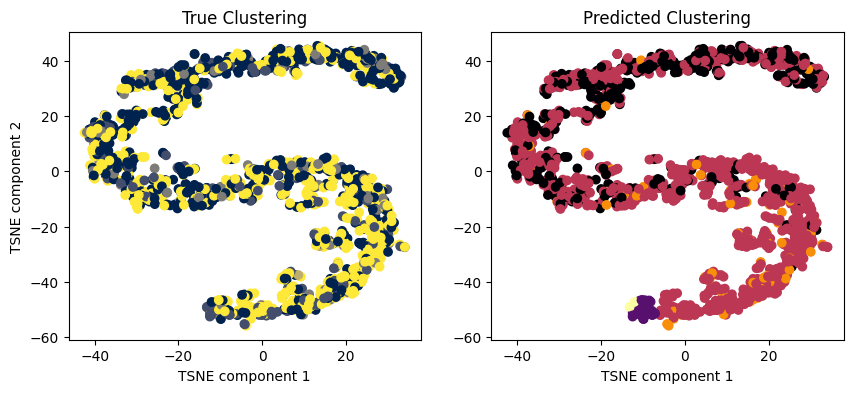

In [66]:
print(GMM.get_entropy())
GMM.visualize_clustering()

#### supervised - Naive Bayes

In [67]:
# supervised method - naive bayes
NB = Naive_Bayes_model(num_classes=5,
                        x_train=X_train_pca,
                        y_train=y_train,
                        x_test=X_test_pca,
                        y_test=y_test)

training accuracy: 58.97%
testing accuracy: 57.50%
None
{'MAX ENTROPY': 2.321928094887362, 0: '1.63', 1: '1.89', 2: '1.88', 3: '1.84', 4: '1.04'}


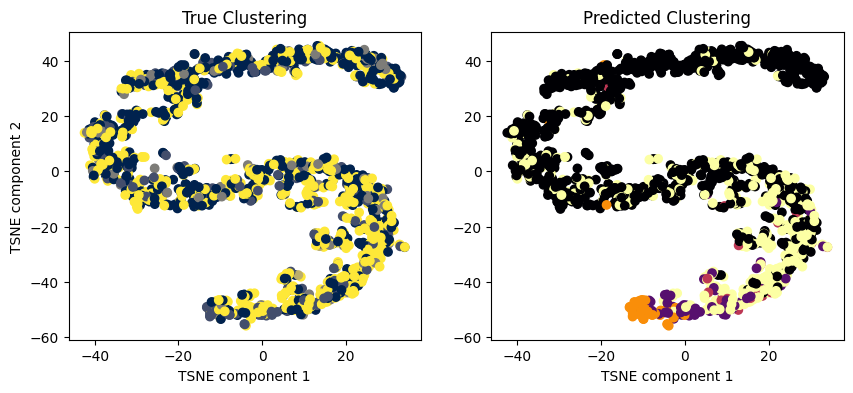

In [68]:
print(NB.get_accuracies())
print(NB.get_entropy())
NB.visualize_clustering()